In [26]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from ModelGrafo import Disciplina

### Criando Disciplinas

In [ ]:
disciplinas = {}


def criar_disciplina(codigo, nome, carga=64):

    d = Disciplina(
        codigo,
        nome,
        carga
    )

    disciplinas[codigo] = d

    return d

# Cadastro das Disciplinas
# ===== 1º SEMESTRE =====

mat00A = criar_disciplina(
    "MAT00A",
    "Cálculo A",
    64
)

xmac01 = criar_disciplina(
    "XMAC01",
    "Matemática Discreta",
    64
)

xdes01 = criar_disciplina(
    "XDES01",
    "Fundamentos de Programação",
    64
)

crsc03 = criar_disciplina(
    "CRSC03",
    "Arquitetura de Computadores I",
    64
)

cahc04 = criar_disciplina(
    "CAHC04",
    "Projeto Integrado",
    32
)

# ===== 2º SEMESTRE =====

mat00B = criar_disciplina(
    "MAT00B",
    "Cálculo B",
    64
)

cmac04 = criar_disciplina(
    "CMAC04",
    "Modelagem Computacional",
    64
)

ctcO01 = criar_disciplina(
    "CTCO01",
    "Algoritmos e Estruturas de Dados I",
    64
)

crsc04 = criar_disciplina(
    "CRSC04",
    "Arquitetura de Computadores II",
    64
)

# ===== 3º SEMESTRE =====

ctco02 = criar_disciplina(
    "CTCO02",
    "Algoritmos e Estruturas de Dados II",
    64
)

cmac03 = criar_disciplina(
    "CMAC03",
    "Algoritmos em Grafos",
    64
)

xmac02 = criar_disciplina(
    "XMAC02",
    "Métodos Matemáticos para Análise de Dados",
    64
)

xdes02 = criar_disciplina(
    "XDES02",
    "Programação Orientada a Objetos",
    64
)

xdes04 = criar_disciplina(
    "XDES04",
    "Engenharia de Software I",
    64
)

crsc02 = criar_disciplina(
    "CRSC02",
    "Sistemas Operacionais",
    64
)


# ===== 4º SEMESTRE =====

xrsc01 = criar_disciplina(
    "XRSC01",
    "Redes de Computadores",
    64
)

crsc05 = criar_disciplina(
    "CRSC05",
    "Sistemas Embarcados",
    64
)

ctco04 = criar_disciplina(
    "CTCO04",
    "Projeto e Análise de Algoritmos",
    64
)

xdes03 = criar_disciplina(
    "XDES03",
    "Programação Web",
    64
)

cdes05 = criar_disciplina(
    "CDES05",
    "Programação Lógica e Funcional",
    64
)

cmac05 = criar_disciplina(
    "CMAC05",
    "Cálculo Numérico para Computação",
    64
)


# ===== 5º SEMESTRE =====

ctco05 = criar_disciplina(
    "CTCO05",
    "Teoria da Computação",
    64
)

xpad01 = criar_disciplina(
    "XPAD01",
    "Banco de Dados I",
    64
)

cmco05 = criar_disciplina(
    "CMCO05",
    "Introdução a Computação Visual",
    64
)

xmco01 = criar_disciplina(
    "XMCO01",
    "Inteligência Artificial",
    64
)

ctco03 = criar_disciplina(
    "CTCO03",
    "Análise e Projeto Orientado a Objetos",
    64
)


# ===== 6º SEMESTRE =====

xahc02 = criar_disciplina(
    "XAHC02",
    "Interação Humano-Computador",
    64
)

ctco06 = criar_disciplina(
    "CTCO06",
    "Compiladores",
    64
)

xahc01 = criar_disciplina(
    "XAHC01",
    "Computação e Sociedade",
    64
)

# ===== 7º SEMESTRE =====

xahc03 = criar_disciplina(
    "XAHC03",
    "Metodologia Científica",
    64
)

tcc1 = criar_disciplina(
    "TCC1",
    "Trabalho de Conclusão de Curso 1",
    140
)

# ===== 8º SEMESTRE =====

tcc2 = criar_disciplina(
    "TCC2",
    "Trabalho de Conclusão de Curso 2",
    210
)

### Adicionando os pré-requisitos

In [28]:
mat00B.adicionar_pre_requisito(mat00A)

cmac04.adicionar_pre_requisito(mat00A)

cmac03.adicionar_pre_requisito(xmac01)

ctcO01.adicionar_pre_requisito(xdes01)

crsc04.adicionar_pre_requisito(crsc03)

ctco02.adicionar_pre_requisito(ctcO01)

xdes02.adicionar_pre_requisito(ctcO01)

crsc02.adicionar_pre_requisito(crsc04)

xmac02.adicionar_pre_requisito(xmac01)  # adicionado: XMAC02 depende de XMAC01

xmco01.adicionar_pre_requisito(xmac02)

cmco05.adicionar_pre_requisito(xmac02)

ctco04.adicionar_pre_requisito(ctco02)

xdes03.adicionar_pre_requisito(xdes02)

xahc02.adicionar_pre_requisito(xdes03)

xrsc01.adicionar_pre_requisito(crsc02)

xpad01.adicionar_pre_requisito(ctco02)

cmac05.adicionar_pre_requisito(mat00B)  # removido MAT00A redundante (MAT00B já exige MAT00A)

cdes05.adicionar_pre_requisito(xmac01)

crsc05.adicionar_pre_requisito(crsc04)

ctco03.adicionar_pre_requisito(xdes02)

ctco05.adicionar_pre_requisito(ctco04)

ctco06.adicionar_pre_requisito(ctco05)

xahc01.adicionar_pre_requisito(xdes04)

tcc1.adicionar_pre_requisito(ctco06)

xahc03.adicionar_pre_requisito(xrsc01)

tcc2.adicionar_pre_requisito(tcc1)

### Criando o Grafo

In [29]:
grafo = nx.DiGraph()


for disciplina in disciplinas.values():

    grafo.add_node(disciplina)



for disciplina in disciplinas.values():

    for requisito in disciplina.pre_requisitos:

        grafo.add_edge(
            requisito,
            disciplina
        )

### Histórico do aluno

In [30]:
df = pd.read_csv("dataset_historico_aluno.csv")
df.head()

,codigo_disciplina,disciplina,carga_horaria,periodo,situacao,nota_final,status
0,MAT00A,Cálculo A,64,2023.1,REP,0.0,Reprovado
1,MAT00A,Cálculo A,64,2023.2,REP,0.1,Reprovado
2,MAT00A,Cálculo A,64,2024.1,REPMF,3.5,Reprovado
3,CAHC04,Projeto Integrado,32,2023.1,APR,7.2,Aprovado
4,CRSC03,Arquitetura de Computadores I,64,2023.1,REP,4.7,Reprovado


In [31]:
def criar_historico(df):
    historico = {}

    df_ordenado = df.sort_values("periodo")  # garante ordem cronológica

    for linha in df_ordenado.itertuples():
        codigo = linha.codigo_disciplina
        situacao = linha.situacao

        if situacao == "APR":
            historico[codigo] = "CONCLUIDA"
        elif situacao in ["REP", "REPMF"]:
            historico[codigo] = "REPROVADA"

    return historico

In [32]:
# Gera o histórico do aluno
historico_aluno = criar_historico(df)


historico_aluno

{'MAT00A': 'REPROVADA',
 'XMAC01': 'CONCLUIDA',
 'CRSC03': 'REPROVADA',
 'XDES01': 'CONCLUIDA',
 'CAHC04': 'CONCLUIDA',
 'IEPG21': 'CONCLUIDA',
 'CDES05': 'CONCLUIDA',
 'CTCO01': 'REPROVADA',
 'ADM51H': 'CONCLUIDA',
 'XDES04': 'CONCLUIDA',
 'XMCO01': 'CONCLUIDA',
 'XAHC01': 'CONCLUIDA',
 'XDES11': 'CONCLUIDA'}

### Atualizar Grafo

In [33]:
for disciplina in disciplinas.values():
    if disciplina.codigo in historico_aluno:
        disciplina.estado = historico_aluno[disciplina.codigo]

### Encontrar Disciplinas disponíveis

In [34]:
def encontrar_disponiveis():

    disponiveis = []


    for disciplina in disciplinas.values():


        if disciplina.estado not in ["NAO_CURSADA", "REPROVADA"]:  

            continue


        liberada = True


        for requisito in disciplina.pre_requisitos:


            if requisito.estado != "CONCLUIDA":

                liberada = False



        if liberada:

            disciplina.estado = "DISPONIVEL"

            disponiveis.append(disciplina)



    return disponiveis

In [35]:
resultado = encontrar_disponiveis()
for d in resultado:
    print(f"{d.codigo} - {d.nome}")

#Essa saida esta um pouco errada: Não há Alg1 nos primeiros semestres

MAT00A - Cálculo A
CRSC03 - Arquitetura de Computadores I
CTCO01 - Algoritmos e Estruturas de Dados I
CMAC03 - Algoritmos em Grafos
XMAC02 - Métodos Matemáticos para Análise de Dados


### Ordenação Topológica

In [36]:
ordem = nx.topological_sort(grafo)


for disciplina in ordem:

    print(
        f"{disciplina.codigo} - {disciplina.nome}"
    )

MAT00A - Cálculo A
XMAC01 - Matemática Discreta
XDES01 - Fundamentos de Programação
CRSC03 - Arquitetura de Computadores I
CAHC04 - Projeto Integrado
XDES04 - Engenharia de Software I
MAT00B - Cálculo B
CMAC04 - Modelagem Computacional
CMAC03 - Algoritmos em Grafos
XMAC02 - Métodos Matemáticos para Análise de Dados
CDES05 - Programação Lógica e Funcional
CTCO01 - Algoritmos e Estruturas de Dados I
CRSC04 - Arquitetura de Computadores II
XAHC01 - Computação e Sociedade
CMAC05 - Cálculo Numérico para Computação
CMCO05 - Introdução a Computação Visual
XMCO01 - Inteligência Artificial
CTCO02 - Algoritmos e Estruturas de Dados II
XDES02 - Programação Orientada a Objetos
CRSC02 - Sistemas Operacionais
CRSC05 - Sistemas Embarcados
CTCO04 - Projeto e Análise de Algoritmos
XPAD01 - Banco de Dados I
XDES03 - Programação Web
CTCO03 - Análise e Projeto Orientado a Objetos
XRSC01 - Redes de Computadores
CTCO05 - Teoria da Computação
XAHC02 - Interação Humano-Computador
XAHC03 - Metodologia Científi

### Mostrar Grafo

C:\Users\jpgto\AppData\Local\Temp\ipykernel_20232\4118023777.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


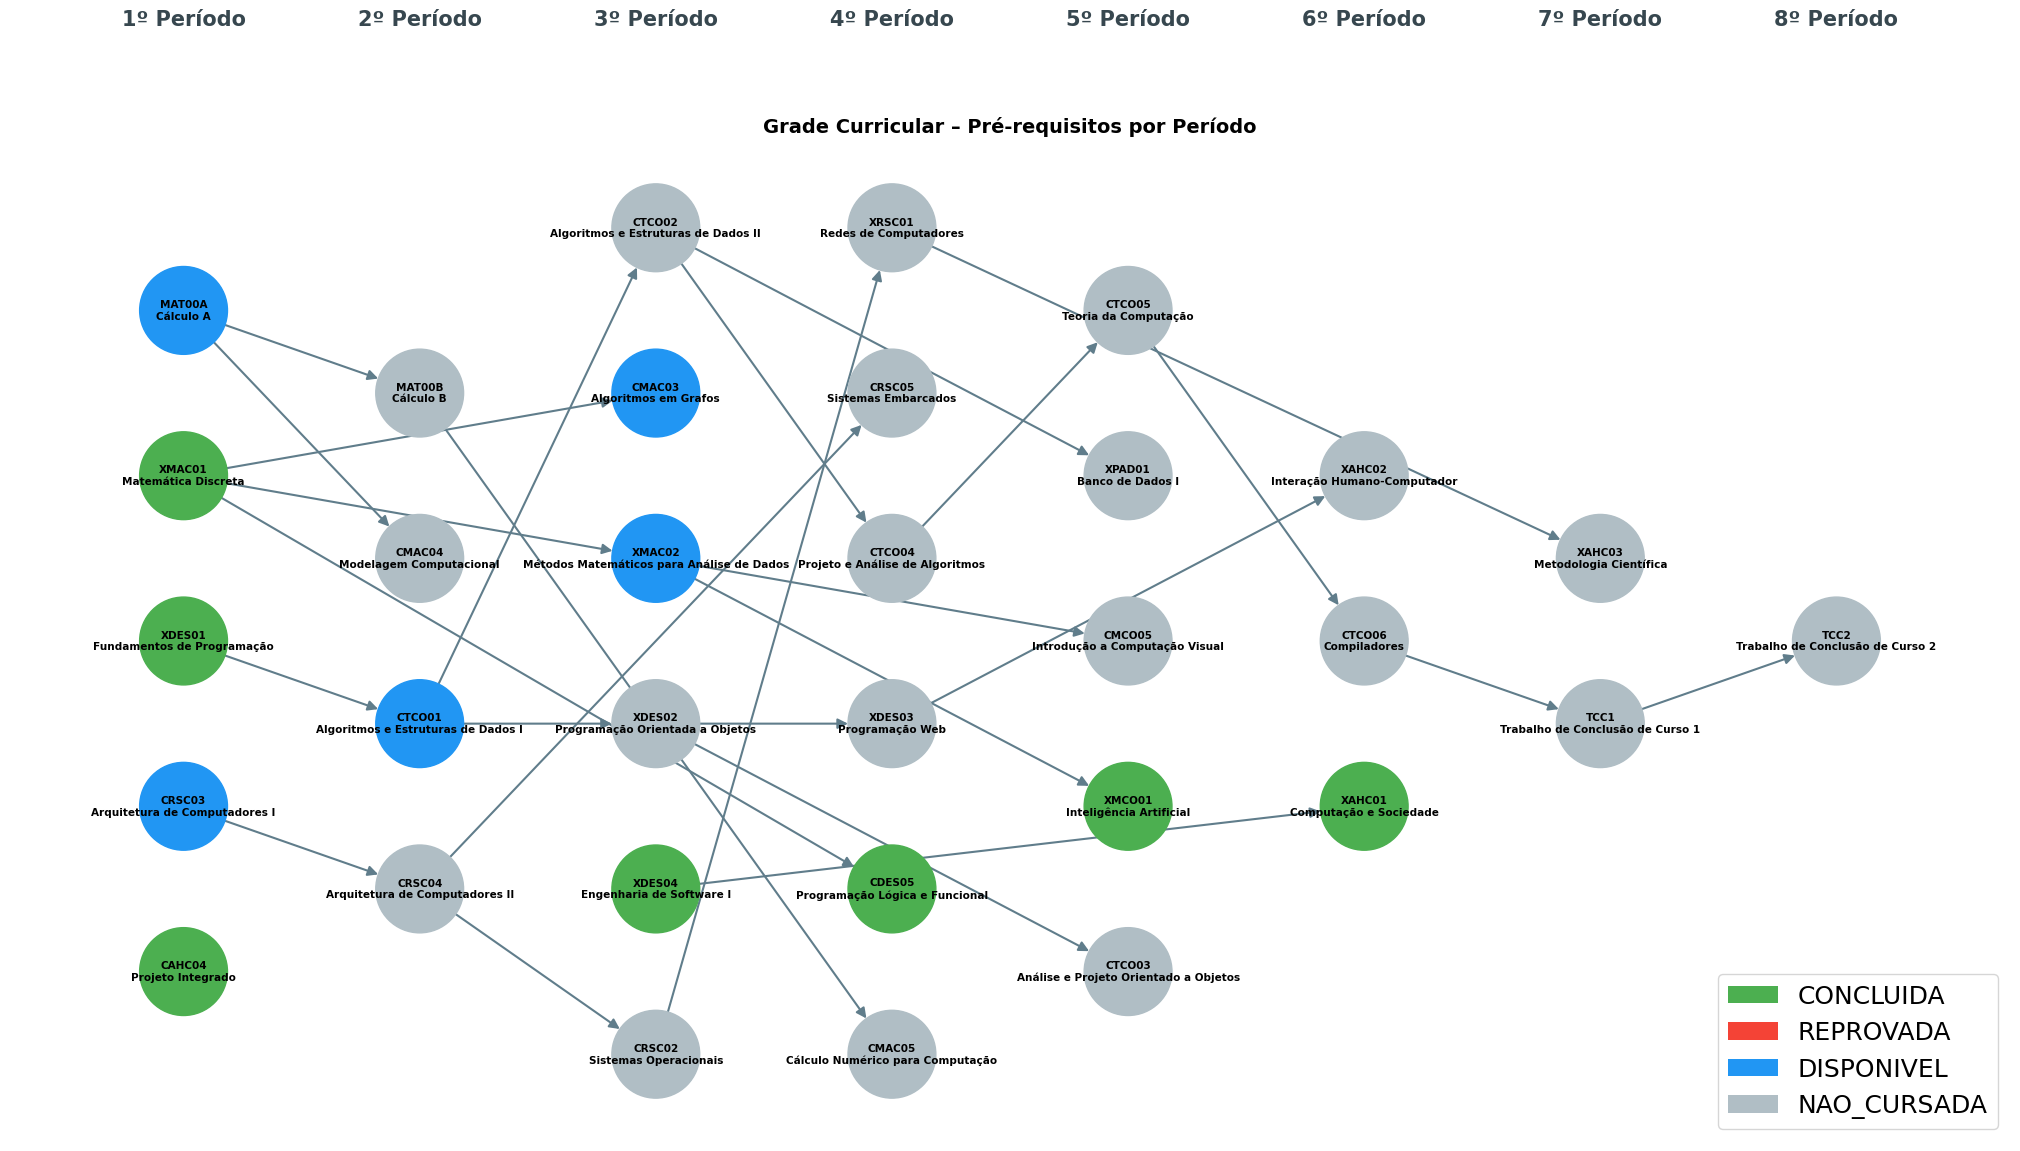

In [45]:
plt.figure(figsize=(20, 10))

# ── Mapeamento semestre → lista de códigos ──────────────────────────────────
semestres = {
    1: ["MAT00A", "XMAC01", "XDES01", "CRSC03", "CAHC04"],
    2: ["MAT00B", "CMAC04", "CTCO01", "CRSC04"],
    3: ["CTCO02", "CMAC03", "XMAC02", "XDES02", "XDES04", "CRSC02"],
    4: ["XRSC01", "CRSC05", "CTCO04", "XDES03", "CDES05", "CMAC05"],
    5: ["CTCO05", "XPAD01", "CMCO05", "XMCO01", "CTCO03"],
    6: ["XAHC02", "CTCO06", "XAHC01"],
    7: ["XAHC03", "TCC1"],
    8: ["TCC2"],
}

# ── Calcula posições: x = semestre, y distribuído verticalmente ─────────────
pos = {}
for sem, codigos in semestres.items():
    n = len(codigos)
    for i, codigo in enumerate(codigos):
        node = disciplinas.get(codigo)
        if node:
            x = sem - 1
            y = (n - 1) / 2 - i
            pos[node] = (x, y)

# ── Nós sem semestre definido ficam abaixo do grafo ─────────────────────────
sem_max = max(semestres.keys())
extra = [n for n in grafo.nodes if n not in pos]
for i, node in enumerate(extra):
    pos[node] = (sem_max + 1, -i)

# ── Cores por estado ─────────────────────────────────────────────────────────
cor_estado = {
    "CONCLUIDA":   "#4CAF50",
    "REPROVADA":   "#F44336",
    "DISPONIVEL":  "#2196F3",
    "NAO_CURSADA": "#B0BEC5",
}
node_colors = [cor_estado.get(getattr(n, "estado", "NAO_CURSADA"), "#B0BEC5")
               for n in grafo.nodes]

labels = {d: f"{d.codigo}\n{d.nome}" for d in grafo.nodes}

nx.draw(
    grafo,
    pos,
    labels=labels,
    with_labels=True,
    node_size=4000,
    node_color=node_colors,
    font_size=7.5,
    font_weight="bold",
    arrows=True,
    arrowsize=15,
    edge_color="#607D8B",
    width=1.5,
)

# ── Rótulos dos semestres no topo ────────────────────────────────────────────
ax = plt.gca()
for sem in semestres:
    ax.text(sem - 1, max(len(v) for v in semestres.values()) / 2 + 0.7,
            f"{sem}º Período",
            ha="center", va="bottom", fontsize=15, fontweight="bold", color="#37474F")

# ── Legenda ──────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legenda = [Patch(facecolor=c, label=s) for s, c in cor_estado.items()]
plt.legend(handles=legenda, loc="lower right", fontsize=18)

plt.title("Grade Curricular – Pré-requisitos por Período", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()